In [ ]:
print("Total samples:", len(df))
print(df['label'].value_counts())

In [ ]:
!pip install datasets

# Dataset 1

In [10]:
from datasets import load_dataset

banking = load_dataset("banking77")

print(banking)
print(banking["train"][0])


DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 10003
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 3080
    })
})
{'text': 'I am still waiting on my card?', 'label': 11}


### maping and extracting banking dataset


In [11]:
from datasets import load_dataset

banking = load_dataset("banking77")

label_names = banking["train"].features["label"].names
print(label_names)

['activate_my_card', 'age_limit', 'apple_pay_or_google_pay', 'atm_support', 'automatic_top_up', 'balance_not_updated_after_bank_transfer', 'balance_not_updated_after_cheque_or_cash_deposit', 'beneficiary_not_allowed', 'cancel_transfer', 'card_about_to_expire', 'card_acceptance', 'card_arrival', 'card_delivery_estimate', 'card_linking', 'card_not_working', 'card_payment_fee_charged', 'card_payment_not_recognised', 'card_payment_wrong_exchange_rate', 'card_swallowed', 'cash_withdrawal_charge', 'cash_withdrawal_not_recognised', 'change_pin', 'compromised_card', 'contactless_not_working', 'country_support', 'declined_card_payment', 'declined_cash_withdrawal', 'declined_transfer', 'direct_debit_payment_not_recognised', 'disposable_card_limits', 'edit_personal_details', 'exchange_charge', 'exchange_rate', 'exchange_via_app', 'extra_charge_on_statement', 'failed_transfer', 'fiat_currency_support', 'get_disposable_virtual_card', 'get_physical_card', 'getting_spare_card', 'getting_virtual_card'

In [12]:
cancel_request = [
    "cancel_transfer",
    "terminate_account"
]
refund_replace = [
    "request_refund",
    "Refund_not_showing_up",
    "reverted_card_payment?",
    "transaction_charged_twice"
]
complaint = [
    "card_not_working",
    "declined_card_payment",
    "declined_cash_withdrawal",
    "declined_transfer",
    "transfer_not_received_by_recipient",
    "wrong_amount_of_cash_received",
    "wrong_exchange_rate_for_cash_withdrawal",
    "card_swallowed",
    "lost_or_stolen_card",
    "virtual_card_not_working",
    "top_up_failed"
]
inquiry = [
    "exchange_rate",
    "card_delivery_estimate",
    "transfer_timing",
    "balance_not_updated_after_bank_transfer",
    "balance_not_updated_after_cheque_or_cash_deposit",
    "country_support",
    "fiat_currency_support",
    "supported_cards_and_currencies",
    "age_limit",
    "visa_or_mastercard"
]
support_request = [
    "activate_my_card",
    "change_pin",
    "edit_personal_details",
    "get_physical_card",
    "get_disposable_virtual_card",
    "getting_virtual_card",
    "getting_spare_card",
    "order_physical_card",
    "passcode_forgotten",
    "pin_blocked",
    "verify_my_identity",
    "verify_source_of_funds",
    "verify_top_up",
    "unable_to_verify_identity"
]

In [13]:
mapping = {}

for label in cancel_request:
    mapping[label] = "cancel_request"

for label in refund_replace:
    mapping[label] = "refund_replace"

for label in complaint:
    mapping[label] = "complaint"

for label in inquiry:
    mapping[label] = "inquiry"

for label in support_request:
    mapping[label] = "support_request"

In [14]:
import pandas as pd

data = []

for example in banking["train"]:
    original_label = banking["train"].features["label"].names[example["label"]]

    if original_label in mapping:
        data.append({
            "text": example["text"],
            "label": mapping[original_label]
        })

expanded_df = pd.DataFrame(data)

print("Total samples:", len(expanded_df))
print(expanded_df['label'].value_counts())

Total samples: 5296
label
support_request    1617
complaint          1414
inquiry            1333
refund_replace      667
cancel_request      265
Name: count, dtype: int64


# Dataset 2

In [9]:
clinc["train"].features["intent"].names[:30]

NameError: name 'clinc' is not defined

In [15]:
from datasets import load_dataset

clinc = load_dataset("clinc_oos", "plus")

print(clinc)
print(clinc["train"][0])

README.md: 0.00B [00:00, ?B/s]

plus/train-00000-of-00001.parquet:   0%|          | 0.00/312k [00:00<?, ?B/s]

plus/validation-00000-of-00001.parquet:   0%|          | 0.00/77.8k [00:00<?, ?B/s]

plus/test-00000-of-00001.parquet:   0%|          | 0.00/136k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/15250 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3100 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5500 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'intent'],
        num_rows: 15250
    })
    validation: Dataset({
        features: ['text', 'intent'],
        num_rows: 3100
    })
    test: Dataset({
        features: ['text', 'intent'],
        num_rows: 5500
    })
})
{'text': 'what expression would i use to say i love you if i were an italian', 'intent': 61}


In [16]:
clinc_labels = clinc["train"].features["intent"].names

mapping_clinc = {
    "restaurant_reviews": "feedback",
    "account_blocked": "complaint",
    "report_lost_card": "complaint",
    "freeze_account": "complaint",
    "bill_balance": "inquiry",
    "interest_rate": "inquiry"
}

clinc_data = []

for example in clinc["train"]:
    original_label = clinc_labels[example["intent"]]

    if original_label in mapping_clinc:
        clinc_data.append({
            "text": example["text"],
            "label": mapping_clinc[original_label]
        })

clinc_df = pd.DataFrame(clinc_data)

print(len(clinc_df))
print(clinc_df['label'].value_counts())

600
label
complaint    300
inquiry      200
feedback     100
Name: count, dtype: int64


In [17]:
final_df = pd.concat([expanded_df, clinc_df])
final_df = final_df.drop_duplicates()

In [18]:
mapping_clinc = {
    "restaurant_reviews": "feedback",
    "account_blocked": "complaint",
    "report_lost_card": "complaint",
    "freeze_account": "complaint",
    "interest_rate": "inquiry",
    "bill_balance": "inquiry",
    "nutrition_info": "inquiry",
    "accept_reservations": "inquiry",
    "redeem_rewards": "support_request",
    "order": "support_request",
    "schedule_meeting": "support_request",
    "change_language": "support_request"
}

clinc_labels = clinc["train"].features["intent"].names

clinc_data = []

for example in clinc["train"]:
    original_label = clinc_labels[example["intent"]]

    if original_label in mapping_clinc:
        clinc_data.append({
            "text": example["text"],
            "label": mapping_clinc[original_label]
        })

clinc_df = pd.DataFrame(clinc_data)

print("CLINC extracted:", len(clinc_df))
print(clinc_df['label'].value_counts())

CLINC extracted: 1200
label
support_request    400
inquiry            400
complaint          300
feedback           100
Name: count, dtype: int64


# # Dataset 3

In [19]:
snips = load_dataset("snips_built_in_intents")

print(snips)
print(snips["train"][0])

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/11.2k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/328 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 328
    })
})
{'text': "Share my location with Hillary's sister", 'label': 5}


In [20]:
snips = load_dataset("snips_built_in_intents")

print(snips)
print(snips["train"].column_names)
print(snips["train"][0])
print(snips["train"].features)
print(snips["train"].column_names)
print(snips["train"].features)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 328
    })
})
['text', 'label']
{'text': "Share my location with Hillary's sister", 'label': 5}
{'text': Value('string'), 'label': ClassLabel(names=['ComparePlaces', 'RequestRide', 'GetWeather', 'SearchPlace', 'GetPlaceDetails', 'ShareCurrentLocation', 'GetTrafficInformation', 'BookRestaurant', 'GetDirections', 'ShareETA'])}
['text', 'label']
{'text': Value('string'), 'label': ClassLabel(names=['ComparePlaces', 'RequestRide', 'GetWeather', 'SearchPlace', 'GetPlaceDetails', 'ShareCurrentLocation', 'GetTrafficInformation', 'BookRestaurant', 'GetDirections', 'ShareETA'])}


In [21]:
snips_labels = snips["train"].features["label"].names

mapping_snips = {
    "GetWeather": "inquiry",
    "GetTrafficInformation": "inquiry",
    "GetPlaceDetails": "inquiry",
    "SearchPlace": "inquiry",
    "BookRestaurant": "support_request",
    "RequestRide": "support_request",
    "GetDirections": "support_request"
}

snips_data = []

for example in snips["train"]:
    original_label = snips_labels[example["label"]]

    if original_label in mapping_snips:
        snips_data.append({
            "text": example["text"],
            "label": mapping_snips[original_label]
        })

snips_df = pd.DataFrame(snips_data)

print("SNIPS extracted:", len(snips_df))
print(snips_df['label'].value_counts())

SNIPS extracted: 271
label
inquiry            140
support_request    131
Name: count, dtype: int64


In [22]:
final_df = pd.concat([expanded_df, clinc_df, snips_df])
final_df = final_df.drop_duplicates().reset_index(drop=True)

print("Final dataset size:", len(final_df))
print(final_df['label'].value_counts())

Final dataset size: 6767
label
support_request    2148
inquiry            1873
complaint          1714
refund_replace      667
cancel_request      265
feedback            100
Name: count, dtype: int64


In [23]:
print("Final dataset size:", len(final_df))
print(final_df['label'].value_counts())

Final dataset size: 6767
label
support_request    2148
inquiry            1873
complaint          1714
refund_replace      667
cancel_request      265
feedback            100
Name: count, dtype: int64


In [24]:
import pandas as pd

# Load the new files you created
app_df = pd.read_csv("appreciation (1).csv")
feed_df = pd.read_csv("feedback (1).csv")

# Make sure column names are correct
print(app_df.columns)
print(feed_df.columns)

# If needed, rename columns to match:
# They must be: text , label

# Merge into existing dataset
final_df = pd.concat([final_df, app_df, feed_df])
final_df = final_df.drop_duplicates().reset_index(drop=True)

print("Final dataset size:", len(final_df))
print(final_df['label'].value_counts())
final_df.to_csv("final_intent_dataset.csv", index=False)

Index(['text', 'label'], dtype='object')
Index(['text', 'label'], dtype='object')
Final dataset size: 7667
label
support_request    2148
inquiry            1873
complaint          1714
refund_replace      667
appreciation        500
cancel_request      265
improvement         103
suggestion          103
feedback            100
positive             99
neutral              95
Name: count, dtype: int64


In [25]:
final_df['label'] = final_df['label'].replace({
    'improvement': 'feedback',
    'suggestion': 'feedback',
    'positive': 'feedback',
    'neutral': 'feedback'
})

print(final_df['label'].value_counts())

label
support_request    2148
inquiry            1873
complaint          1714
refund_replace      667
feedback            500
appreciation        500
cancel_request      265
Name: count, dtype: int64


In [26]:
final_df.to_csv("final_intent_dataset.csv", index=False)
import os
print(os.listdir())

['.config', 'chatbot_emotion_dataset_15000_clean.csv', 'appreciation (1).csv', 'feedback (1).csv', 'cleaned_dataset_intent.csv', 'final_intent_dataset.csv', 'sample_data']


## FULL INTENT TRAINING CODE

In [27]:
print("Total samples:", len(df))
print(df['label'].value_counts())

NameError: name 'df' is not defined

In [28]:
!pip install datasets

# Dataset 1

In [29]:
from datasets import load_dataset

banking = load_dataset("banking77")

print(banking)
print(banking["train"][0])


DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 10003
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 3080
    })
})
{'text': 'I am still waiting on my card?', 'label': 11}


### maping and extracting banking dataset


In [30]:
from datasets import load_dataset

banking = load_dataset("banking77")

label_names = banking["train"].features["label"].names
print(label_names)

['activate_my_card', 'age_limit', 'apple_pay_or_google_pay', 'atm_support', 'automatic_top_up', 'balance_not_updated_after_bank_transfer', 'balance_not_updated_after_cheque_or_cash_deposit', 'beneficiary_not_allowed', 'cancel_transfer', 'card_about_to_expire', 'card_acceptance', 'card_arrival', 'card_delivery_estimate', 'card_linking', 'card_not_working', 'card_payment_fee_charged', 'card_payment_not_recognised', 'card_payment_wrong_exchange_rate', 'card_swallowed', 'cash_withdrawal_charge', 'cash_withdrawal_not_recognised', 'change_pin', 'compromised_card', 'contactless_not_working', 'country_support', 'declined_card_payment', 'declined_cash_withdrawal', 'declined_transfer', 'direct_debit_payment_not_recognised', 'disposable_card_limits', 'edit_personal_details', 'exchange_charge', 'exchange_rate', 'exchange_via_app', 'extra_charge_on_statement', 'failed_transfer', 'fiat_currency_support', 'get_disposable_virtual_card', 'get_physical_card', 'getting_spare_card', 'getting_virtual_card'

In [31]:
cancel_request = [
    "cancel_transfer",
    "terminate_account"
]
refund_replace = [
    "request_refund",
    "Refund_not_showing_up",
    "reverted_card_payment?",
    "transaction_charged_twice"
]
complaint = [
    "card_not_working",
    "declined_card_payment",
    "declined_cash_withdrawal",
    "declined_transfer",
    "transfer_not_received_by_recipient",
    "wrong_amount_of_cash_received",
    "wrong_exchange_rate_for_cash_withdrawal",
    "card_swallowed",
    "lost_or_stolen_card",
    "virtual_card_not_working",
    "top_up_failed"
]
inquiry = [
    "exchange_rate",
    "card_delivery_estimate",
    "transfer_timing",
    "balance_not_updated_after_bank_transfer",
    "balance_not_updated_after_cheque_or_cash_deposit",
    "country_support",
    "fiat_currency_support",
    "supported_cards_and_currencies",
    "age_limit",
    "visa_or_mastercard"
]
support_request = [
    "activate_my_card",
    "change_pin",
    "edit_personal_details",
    "get_physical_card",
    "get_disposable_virtual_card",
    "getting_virtual_card",
    "getting_spare_card",
    "order_physical_card",
    "passcode_forgotten",
    "pin_blocked",
    "verify_my_identity",
    "verify_source_of_funds",
    "verify_top_up",
    "unable_to_verify_identity"
]

In [32]:
mapping = {}

for label in cancel_request:
    mapping[label] = "cancel_request"

for label in refund_replace:
    mapping[label] = "refund_replace"

for label in complaint:
    mapping[label] = "complaint"

for label in inquiry:
    mapping[label] = "inquiry"

for label in support_request:
    mapping[label] = "support_request"

In [33]:
import pandas as pd

data = []

for example in banking["train"]:
    original_label = banking["train"].features["label"].names[example["label"]]

    if original_label in mapping:
        data.append({
            "text": example["text"],
            "label": mapping[original_label]
        })

expanded_df = pd.DataFrame(data)

print("Total samples:", len(expanded_df))
print(expanded_df['label'].value_counts())

Total samples: 5296
label
support_request    1617
complaint          1414
inquiry            1333
refund_replace      667
cancel_request      265
Name: count, dtype: int64


# Dataset 2

In [34]:
clinc["train"].features["intent"].names[:30]

['restaurant_reviews',
 'nutrition_info',
 'account_blocked',
 'oil_change_how',
 'time',
 'weather',
 'redeem_rewards',
 'interest_rate',
 'gas_type',
 'accept_reservations',
 'smart_home',
 'user_name',
 'report_lost_card',
 'repeat',
 'whisper_mode',
 'what_are_your_hobbies',
 'order',
 'jump_start',
 'schedule_meeting',
 'meeting_schedule',
 'freeze_account',
 'what_song',
 'meaning_of_life',
 'restaurant_reservation',
 'traffic',
 'make_call',
 'text',
 'bill_balance',
 'improve_credit_score',
 'change_language']

In [35]:
from datasets import load_dataset

clinc = load_dataset("clinc_oos", "plus")

print(clinc)
print(clinc["train"][0])

DatasetDict({
    train: Dataset({
        features: ['text', 'intent'],
        num_rows: 15250
    })
    validation: Dataset({
        features: ['text', 'intent'],
        num_rows: 3100
    })
    test: Dataset({
        features: ['text', 'intent'],
        num_rows: 5500
    })
})
{'text': 'what expression would i use to say i love you if i were an italian', 'intent': 61}


In [36]:
clinc_labels = clinc["train"].features["intent"].names

mapping_clinc = {
    "restaurant_reviews": "feedback",
    "account_blocked": "complaint",
    "report_lost_card": "complaint",
    "freeze_account": "complaint",
    "bill_balance": "inquiry",
    "interest_rate": "inquiry"
}

clinc_data = []

for example in clinc["train"]:
    original_label = clinc_labels[example["intent"]]

    if original_label in mapping_clinc:
        clinc_data.append({
            "text": example["text"],
            "label": mapping_clinc[original_label]
        })

clinc_df = pd.DataFrame(clinc_data)

print(len(clinc_df))
print(clinc_df['label'].value_counts())

600
label
complaint    300
inquiry      200
feedback     100
Name: count, dtype: int64


In [37]:
final_df = pd.concat([expanded_df, clinc_df])
final_df = final_df.drop_duplicates()

In [38]:
mapping_clinc = {
    "restaurant_reviews": "feedback",
    "account_blocked": "complaint",
    "report_lost_card": "complaint",
    "freeze_account": "complaint",
    "interest_rate": "inquiry",
    "bill_balance": "inquiry",
    "nutrition_info": "inquiry",
    "accept_reservations": "inquiry",
    "redeem_rewards": "support_request",
    "order": "support_request",
    "schedule_meeting": "support_request",
    "change_language": "support_request"
}

clinc_labels = clinc["train"].features["intent"].names

clinc_data = []

for example in clinc["train"]:
    original_label = clinc_labels[example["intent"]]

    if original_label in mapping_clinc:
        clinc_data.append({
            "text": example["text"],
            "label": mapping_clinc[original_label]
        })

clinc_df = pd.DataFrame(clinc_data)

print("CLINC extracted:", len(clinc_df))
print(clinc_df['label'].value_counts())

CLINC extracted: 1200
label
support_request    400
inquiry            400
complaint          300
feedback           100
Name: count, dtype: int64


# # Dataset 3

In [39]:
snips = load_dataset("snips_built_in_intents")

print(snips)
print(snips["train"][0])

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 328
    })
})
{'text': "Share my location with Hillary's sister", 'label': 5}


In [40]:
snips = load_dataset("snips_built_in_intents")

print(snips)
print(snips["train"].column_names)
print(snips["train"][0])
print(snips["train"].features)
print(snips["train"].column_names)
print(snips["train"].features)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 328
    })
})
['text', 'label']
{'text': "Share my location with Hillary's sister", 'label': 5}
{'text': Value('string'), 'label': ClassLabel(names=['ComparePlaces', 'RequestRide', 'GetWeather', 'SearchPlace', 'GetPlaceDetails', 'ShareCurrentLocation', 'GetTrafficInformation', 'BookRestaurant', 'GetDirections', 'ShareETA'])}
['text', 'label']
{'text': Value('string'), 'label': ClassLabel(names=['ComparePlaces', 'RequestRide', 'GetWeather', 'SearchPlace', 'GetPlaceDetails', 'ShareCurrentLocation', 'GetTrafficInformation', 'BookRestaurant', 'GetDirections', 'ShareETA'])}


In [41]:
snips_labels = snips["train"].features["label"].names

mapping_snips = {
    "GetWeather": "inquiry",
    "GetTrafficInformation": "inquiry",
    "GetPlaceDetails": "inquiry",
    "SearchPlace": "inquiry",
    "BookRestaurant": "support_request",
    "RequestRide": "support_request",
    "GetDirections": "support_request"
}

snips_data = []

for example in snips["train"]:
    original_label = snips_labels[example["label"]]

    if original_label in mapping_snips:
        snips_data.append({
            "text": example["text"],
            "label": mapping_snips[original_label]
        })

snips_df = pd.DataFrame(snips_data)

print("SNIPS extracted:", len(snips_df))
print(snips_df['label'].value_counts())

SNIPS extracted: 271
label
inquiry            140
support_request    131
Name: count, dtype: int64


In [42]:
final_df = pd.concat([expanded_df, clinc_df, snips_df])
final_df = final_df.drop_duplicates().reset_index(drop=True)

print("Final dataset size:", len(final_df))
print(final_df['label'].value_counts())

Final dataset size: 6767
label
support_request    2148
inquiry            1873
complaint          1714
refund_replace      667
cancel_request      265
feedback            100
Name: count, dtype: int64


In [43]:
print("Final dataset size:", len(final_df))
print(final_df['label'].value_counts())

Final dataset size: 6767
label
support_request    2148
inquiry            1873
complaint          1714
refund_replace      667
cancel_request      265
feedback            100
Name: count, dtype: int64


In [44]:
import pandas as pd

# Load the new files you created
app_df = pd.read_csv("appreciation (1).csv")
feed_df = pd.read_csv("feedback (1).csv")

# Make sure column names are correct
print(app_df.columns)
print(feed_df.columns)

# If needed, rename columns to match:
# They must be: text , label

# Merge into existing dataset
final_df = pd.concat([final_df, app_df, feed_df])
final_df = final_df.drop_duplicates().reset_index(drop=True)

print("Final dataset size:", len(final_df))
print(final_df['label'].value_counts())
final_df.to_csv("final_intent_dataset.csv", index=False)

Index(['text', 'label'], dtype='object')
Index(['text', 'label'], dtype='object')
Final dataset size: 7667
label
support_request    2148
inquiry            1873
complaint          1714
refund_replace      667
appreciation        500
cancel_request      265
improvement         103
suggestion          103
feedback            100
positive             99
neutral              95
Name: count, dtype: int64


In [45]:
final_df['label'] = final_df['label'].replace({
    'improvement': 'feedback',
    'suggestion': 'feedback',
    'positive': 'feedback',
    'neutral': 'feedback'
})

print(final_df['label'].value_counts())

label
support_request    2148
inquiry            1873
complaint          1714
refund_replace      667
feedback            500
appreciation        500
cancel_request      265
Name: count, dtype: int64


In [46]:
final_df.to_csv("final_intent_dataset.csv", index=False)
import os
print(os.listdir())

['.config', 'chatbot_emotion_dataset_15000_clean.csv', 'appreciation (1).csv', 'feedback (1).csv', 'cleaned_dataset_intent.csv', 'final_intent_dataset.csv', 'sample_data']


## FULL INTENT TRAINING CODE

In [47]:
import torch
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)

from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils import clip_grad_norm_
from tqdm import tqdm

In [48]:
import pandas as pd

df = pd.read_csv("final_intent_dataset.csv")

print("Total samples:", len(df))
print(df['label'].value_counts())

Total samples: 7667
label
support_request    2148
inquiry            1873
complaint          1714
refund_replace      667
feedback            500
appreciation        500
cancel_request      265
Name: count, dtype: int64


## Proper 70 / 15 / 15 Split

In [49]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df['label'],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df['label'],
    random_state=42
)

print(len(train_df), len(val_df), len(test_df))

5366 1150 1151


## Encode labels

In [50]:
label_encoder = LabelEncoder()

train_df['label_enc'] = label_encoder.fit_transform(train_df['label'])
val_df['label_enc'] = label_encoder.transform(val_df['label'])
test_df['label_enc'] = label_encoder.transform(test_df['label'])

num_labels = len(label_encoder.classes_)
print("Number of classes:", num_labels)

Number of classes: 7


## Create dataset class

In [51]:
class IntentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=64):
        self.texts = texts.tolist()
        self.labels = labels.tolist()
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            padding='max_length',
            truncation=True,
            max_length=self.max_len,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(self.labels[idx], dtype=torch.long)
        }

## Initialize Model (roberta-base)

In [52]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

tokenizer = AutoTokenizer.from_pretrained("roberta-base")

model = AutoModelForSequenceClassification.from_pretrained(
    "roberta-base",
    num_labels=num_labels
).to(device)

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


## Compute class weights ad create dataloaders

In [53]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_df['label_enc']),
    y=train_df['label_enc']
)

class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

loss_fn = torch.nn.CrossEntropyLoss(weight=class_weights)
train_dataset = IntentDataset(
    train_df['text'],
    train_df['label_enc'],
    tokenizer
)

val_dataset = IntentDataset(
    val_df['text'],
    val_df['label_enc'],
    tokenizer
)

test_dataset = IntentDataset(
    test_df['text'],
    test_df['label_enc'],
    tokenizer
)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16)
test_loader = DataLoader(test_dataset, batch_size=16)

## optimize+scheduler

In [54]:
optimizer = AdamW(model.parameters(), lr=2e-5)

total_steps = len(train_loader) * 5

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)

## Training Loop (With Early Stopping)

In [55]:
best_val_loss = float('inf')
patience = 2
counter = 0

for epoch in range(5):

    model.train()
    train_loss = 0

    for batch in tqdm(train_loader):
        optimizer.zero_grad()

        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids, attention_mask=attention_mask)
        loss = loss_fn(outputs.logits, labels)

        loss.backward()
        clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()
        scheduler.step()

        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)

    # Validation
    model.eval()
    val_loss = 0

    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids, attention_mask=attention_mask)
            loss = loss_fn(outputs.logits, labels)

            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader)

    print(f"\nEpoch {epoch+1}")
    print("Train Loss:", avg_train_loss)
    print("Val Loss:", avg_val_loss)

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        counter = 0
        torch.save(model.state_dict(), "best_intent_model.pt")
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered")
            break

100%|██████████| 336/336 [01:08<00:00,  4.92it/s]



Epoch 1
Train Loss: 0.8179791677587976
Val Loss: 0.1494747504281501


100%|██████████| 336/336 [01:11<00:00,  4.68it/s]



Epoch 2
Train Loss: 0.10020903757304907
Val Loss: 0.09045568146231947


100%|██████████| 336/336 [01:11<00:00,  4.71it/s]



Epoch 3
Train Loss: 0.0442255821343722
Val Loss: 0.10645209939684719


100%|██████████| 336/336 [01:11<00:00,  4.73it/s]



Epoch 4
Train Loss: 0.018386683173524772
Val Loss: 0.09729574502206459
Early stopping triggered


## Final Evaluation on TEST


TEST RESULTS
                 precision    recall  f1-score   support

   appreciation       1.00      1.00      1.00        75
 cancel_request       0.98      1.00      0.99        40
      complaint       0.97      0.98      0.97       257
       feedback       1.00      0.96      0.98        75
        inquiry       0.97      0.97      0.97       281
 refund_replace       0.99      0.95      0.97       100
support_request       0.98      0.98      0.98       323

       accuracy                           0.98      1151
      macro avg       0.98      0.98      0.98      1151
   weighted avg       0.98      0.98      0.98      1151



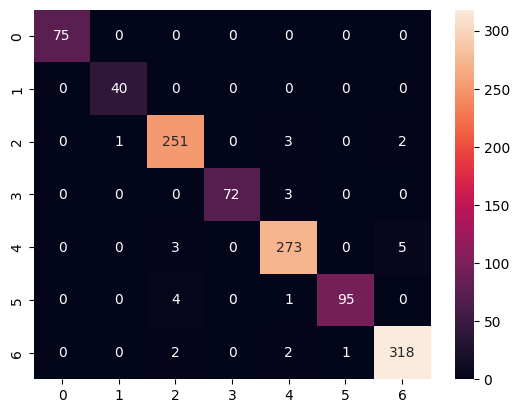

In [56]:
model.load_state_dict(torch.load("best_intent_model.pt"))
model.eval()

preds = []
true_labels = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids, attention_mask=attention_mask)
        predictions = torch.argmax(outputs.logits, dim=1)

        preds.extend(predictions.cpu().numpy())
        true_labels.extend(labels.cpu().numpy())

print("\nTEST RESULTS")
print(classification_report(
    true_labels,
    preds,
    target_names=label_encoder.classes_
))

cm = confusion_matrix(true_labels, preds)
sns.heatmap(cm, annot=True, fmt='d')
plt.show()

In [58]:
train_texts = set(train_df['text'])
test_texts = set(test_df['text'])

overlap = train_texts.intersection(test_texts)
print("Train-Test Overlap:", len(overlap))

Train-Test Overlap: 0


In [59]:
print("Total duplicates:", df.duplicated(subset=["text"]).sum())

Total duplicates: 0


In [60]:
print(test_df['label'].value_counts())

label
support_request    323
inquiry            281
complaint          257
refund_replace     100
appreciation        75
feedback            75
cancel_request      40
Name: count, dtype: int64


In [61]:
shuffled_labels = np.random.permutation(train_df['label_enc'])

## Save the model

In [57]:
model.save_pretrained("intent_model")
tokenizer.save_pretrained("intent_model")
torch.save(label_encoder, "intent_label_encoder.pt")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [65]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [64]:
!ls

'appreciation (1).csv'			   final_intent_dataset.csv
 best_intent_model.pt			   intent_label_encoder.pt
 chatbot_emotion_dataset_15000_clean.csv   intent_model
 cleaned_dataset_intent.csv		   sample_data
'feedback (1).csv'


In [ ]:
from google.colab import _message
from google.colab import files
import json

# Get notebook JSON
nb = _message.blocking_request('get_ipynb', timeout_sec=5)

# Extract notebook name safely
metadata = nb.get('ipynb', {}).get('metadata', {})
colab_meta = metadata.get('colab', {})

nb_name = colab_meta.get('name', 'downloaded_notebook.ipynb')

print("Notebook name:", nb_name)

# Save notebook to runtime
with open(nb_name, 'w') as f:
    json.dump(nb['ipynb'], f)

# Download to your computer
files.download(nb_name)